<a href="https://colab.research.google.com/github/AR-Ashik-9997/Phitron-practice-problem/blob/main/Copy_of_Hand_Written_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Loading the dataset

In [38]:
train_images = np.load('/content/train_images.npy')
train_labels = np.load('/content/train_labels.npy')
test_images = np.load('/content/test_images.npy')
test_labels = np.load('/content/test_labels.npy')

train_images.shape
train_images[0].shape
test_images.shape

(10000, 28, 28)

In [39]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [40]:
train_labels[0]

np.uint8(5)

In [41]:
# tensordataset example

features = torch.tensor([[1.0,2.0], [3.0,4.0] , [5.0,6.0]])
labels = torch.tensor([0,1,0])

dataset = TensorDataset(features, labels)

dataset[1]

(tensor([3., 4.]), tensor(1))

In [42]:
# dataloader

dataloader = DataLoader (dataset , batch_size = 2, shuffle = True)

for batch in dataloader :
  features , label = batch
  print("feature :", features)
  print("label :", label)

feature : tensor([[3., 4.],
        [1., 2.]])
label : tensor([1, 0])
feature : tensor([[5., 6.]])
label : tensor([0])


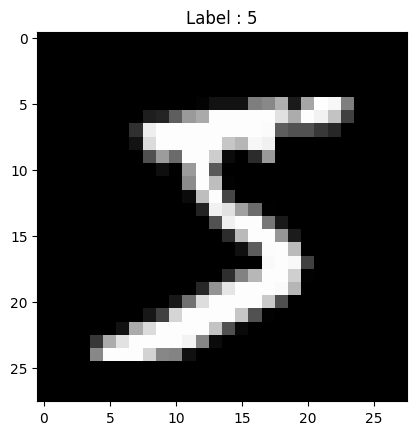

In [43]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0] , cmap ='gray')
plt.title(f'Label : {train_labels[0]}')

plt.show()


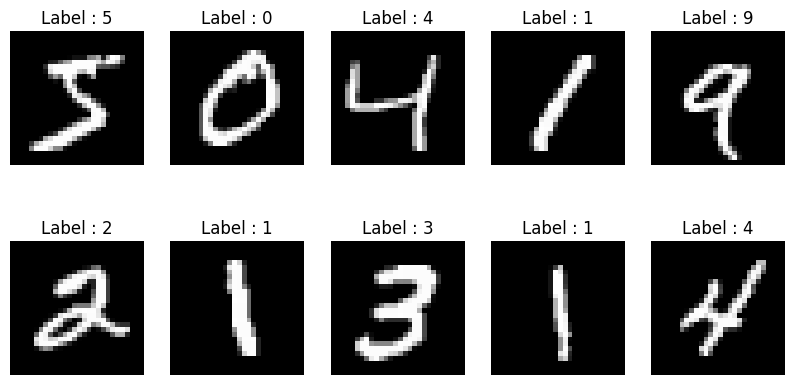

In [44]:
fig , axes = plt.subplots(2, 5 , figsize=(10,5))
axes = axes.flatten()

for i in range(10):
  axes[i].imshow(train_images[i] , cmap='gray')
  axes[i].set_title(f'Label : {train_labels[i]}')
  axes[i].axis('off')


plt.show()


In [45]:
from sklearn.model_selection import train_test_split

X_train_np , X_val_np , y_train_np , y_val_np = train_test_split( train_images, train_labels , test_size=0.1 , random_state=42)


X_train = torch.tensor(X_train_np , dtype = torch.float32)
y_train = torch.tensor(y_train_np , dtype = torch.long)

X_val = torch.tensor(X_val_np, dtype = torch.float32)
y_val = torch.tensor(y_val_np , dtype = torch.long)


X_test = torch.tensor(test_images , dtype = torch.float32)
y_test = torch.tensor(test_labels ,dtype = torch.long )


In [46]:
X_train.shape

torch.Size([54000, 28, 28])

In [47]:
train_dataset = TensorDataset(X_train,y_train)
val_dataset = TensorDataset(X_val,y_val)
test_dataset = TensorDataset(X_test,y_test)


train_loader = DataLoader(train_dataset ,batch_size=64 , shuffle = True)
val_loader = DataLoader(val_dataset ,batch_size=64 , shuffle = False)
test_loader = DataLoader(test_dataset ,batch_size=64 , shuffle = False)


In [48]:
class DigitClassificationModel(nn.Module):
  def __init__(self , input_size, num_classes):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size , 128 ), # 1st layer = 128 ta neuron
        nn.ReLU(),
        nn.Linear(128,64), # 2nd layer e 64 ta neuron
        nn.ReLU(),
        nn.Linear(64,num_classes) #Output layer
    )

  def forward(self , features):
    output = self.network(features)
    return output


In [49]:
model =  DigitClassificationModel(input_size = 28*28 , num_classes=10)
print(model)

DigitClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [50]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr= 0.01)

In [55]:
epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
for epoch in range(epochs):

  running_loss = 0.0
  train_correct = 0
  train_total = 0

  for images,labels in train_loader :
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs,labels )
    loss.backward()
    optimizer.step()
    running_loss+= loss.item()
    preds=torch.argmax(outputs,dim=1)
    train_correct+=(preds==labels).sum().item()
    train_total+=labels.size(0)

  epoch_train_loss = running_loss / len(train_loader)
  epoch_train_acc = (train_correct / train_total) * 100
  train_losses.append(epoch_train_loss)
  train_accuracies.append(epoch_train_acc)

  val_loss = 0.0
  val_correct = 0
  val_total = 0


  with torch.no_grad():
    for images,labels in val_loader :
      outputs = model(images)
      loss = criterion(outputs,labels)
      val_loss+= loss.item()
      preds = torch.argmax(outputs,dim=1)
      val_correct += (preds == labels).sum().item()
      val_total += labels.size(0)

  epoch_val_loss = val_loss / len(val_loader)
  epoch_val_acc = (val_correct / val_total) * 100

  val_losses.append(epoch_val_loss)
  val_accuracies.append(epoch_val_acc)

  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {epoch_train_loss:.4f} | Validation Loss: {epoch_val_loss:.4f}'
  )


Epoch 1/ 10 | Train Loss : 0.1148 | Validation Loss: 0.1669
Epoch 2/ 10 | Train Loss : 0.1149 | Validation Loss: 0.1701
Epoch 3/ 10 | Train Loss : 0.1130 | Validation Loss: 0.1770
Epoch 4/ 10 | Train Loss : 0.1091 | Validation Loss: 0.1855
Epoch 5/ 10 | Train Loss : 0.1089 | Validation Loss: 0.1839
Epoch 6/ 10 | Train Loss : 0.1065 | Validation Loss: 0.1962
Epoch 7/ 10 | Train Loss : 0.1016 | Validation Loss: 0.1646
Epoch 8/ 10 | Train Loss : 0.1022 | Validation Loss: 0.1611
Epoch 9/ 10 | Train Loss : 0.0964 | Validation Loss: 0.1802
Epoch 10/ 10 | Train Loss : 0.0976 | Validation Loss: 0.1573


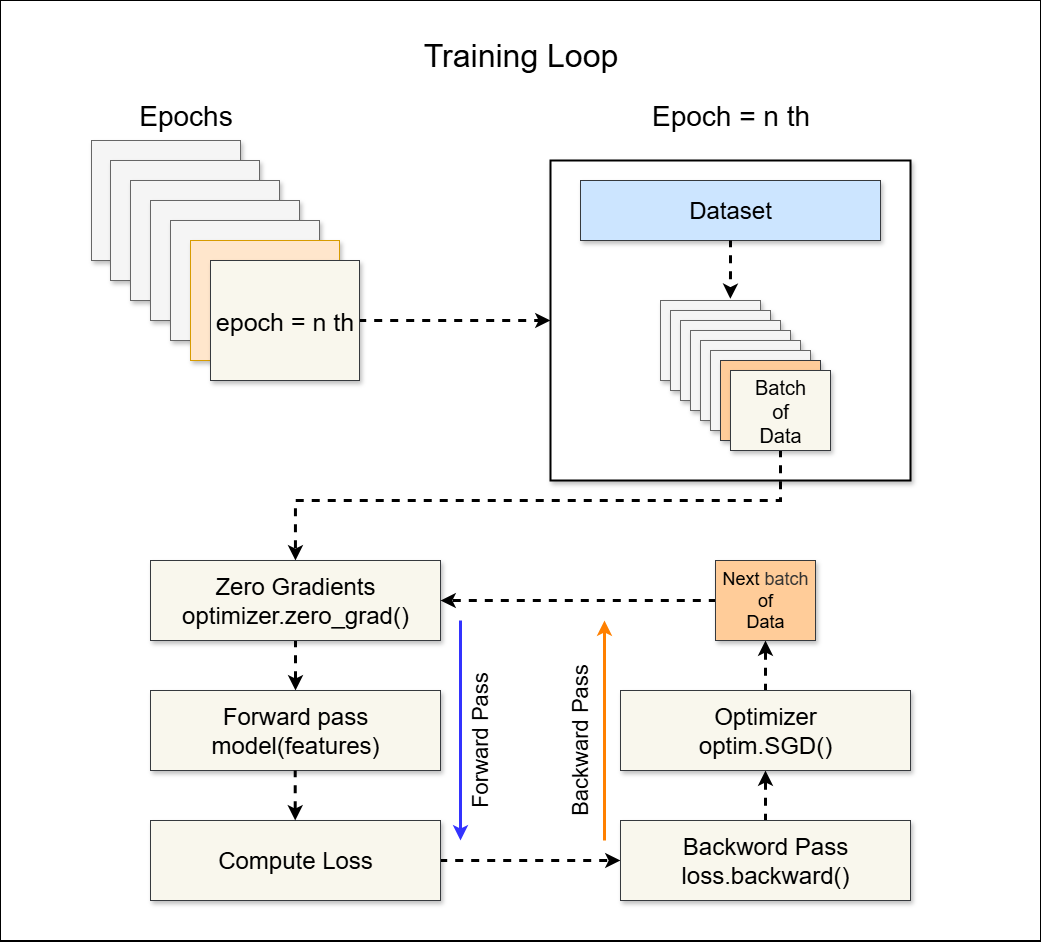

HW: Accuracy Report , Confusion Matrix

In [57]:
from sklearn.metrics import accuracy_score
all_preds=[]
all_labels=[]
with torch.no_grad():
  for images,labels in test_loader:
    outputs=model(images)
    preds=torch.argmax(outputs,dim=1)
    all_preds.extend(preds.tolist())
    all_labels.extend(labels.tolist())
test_accuracy=accuracy_score(all_labels,all_preds)*100
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 95.89%


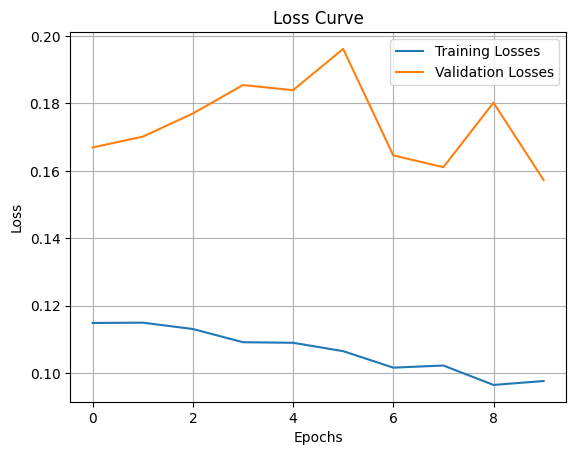

In [58]:
plt.plot(train_losses,label='Training Losses')
plt.plot(val_losses,label='Validation Losses')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

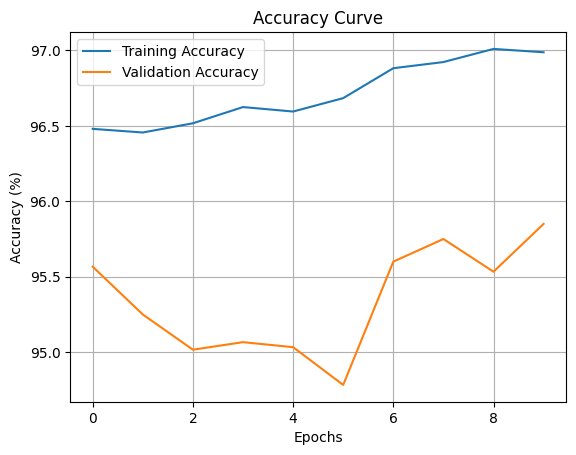

In [59]:
plt.plot(train_accuracies,label='Training Accuracy')
plt.plot(val_accuracies,label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

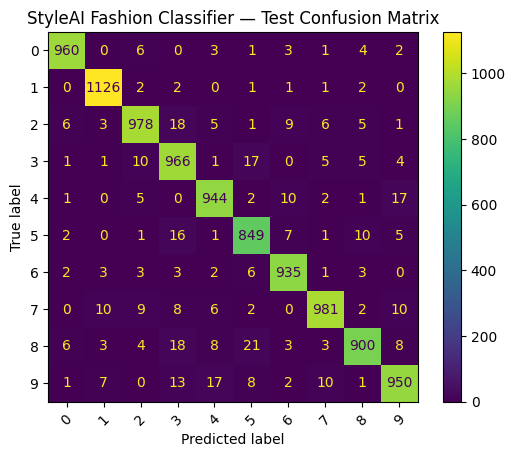

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
cm=confusion_matrix(all_labels,all_preds)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')
plt.title("StyleAI Fashion Classifier — Test Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

In [65]:
from sklearn.metrics import classification_report

# YOUR CODE HERE
reports=classification_report(all_labels,all_preds)
print(reports)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.95      0.95      1032
           3       0.93      0.96      0.94      1010
           4       0.96      0.96      0.96       982
           5       0.94      0.95      0.94       892
           6       0.96      0.98      0.97       958
           7       0.97      0.95      0.96      1028
           8       0.96      0.92      0.94       974
           9       0.95      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

